## Import Libraries

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [75]:
df = pd.read_csv("../data/raw/telco-customer.csv")

## Data Overview

In [76]:
df.shape

(7043, 21)

In [77]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [78]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


### Dataset Description (Telco Customer Churn)

- customerID: รหัสประจำตัวลูกค้าแต่ละราย ใช้ระบุตัวตนของลูกค้า (Unique ID)
- gender: เพศของลูกค้า (Male, Female)
- SeniorCitizen: ลูกค้าเป็นผู้สูงอายุหรือไม่ (`1` = ใช่, `0` = ไม่ใช่)
- Partner: ลูกค้ามีคู่สมรสหรือคู่ชีวิตหรือไม่ (`Yes` = มี, `No` = ไม่มี)
- Dependents: ลูกค้ามีผู้ที่ต้องดูแล (บุตรหรือสมาชิกในครอบครัว) หรือไม่ (`Yes` = มี, `No` = ไม่มี)
- tenure: ระยะเวลาที่ลูกค้าใช้บริการกับบริษัท (หน่วยเป็นเดือน)
- PhoneService: ลูกค้าใช้บริการโทรศัพท์หรือไม่ (`Yes` = ใช้, No` = ไม่ใช้)
- MultipleLines: ลูกค้ามีหมายเลขโทรศัพท์หลายสายหรือไม่ (`Yes` = มีหลายสาย, `No` = มีสายเดียว, `No phone service` = ไม่มีบริการโทรศัพท์)
- InternetService: ประเภทบริการอินเทอร์เน็ตที่ลูกค้าใช้ (`DSL`, `Fiber optic`, `No`)
- OnlineSecurity: มีบริการรักษาความปลอดภัยออนไลน์หรือไม่ (`Yes`, `No`, `No internet service`)
- OnlineBackup: มีบริการสำรองข้อมูลออนไลน์หรือไม่ (`Yes`, `No`, `No internet service`)
- DeviceProtection: มีบริการป้องกันอุปกรณ์หรือไม่ (`Yes`, `No`, `No internet service`)
- TechSupport: มีบริการสนับสนุนทางเทคนิคหรือไม่ (`Yes`, `No`, `No internet service`)
- StreamingTV: มีบริการรับชมทีวีผ่านอินเทอร์เน็ตหรือไม่ (`Yes`, `No`, `No internet service`)
- StreamingMovies: มีบริการรับชมภาพยนตร์ผ่านอินเทอร์เน็ตหรือไม่ (`Yes`, `No`, `No internet service`)
- Contract: ประเภทสัญญาของลูกค้า (`Month-to-month` : รายเดือน, `One year` : รายปี, `Two year` : สองปี)
- PaperlessBilling: ลูกค้าเลือกใช้ใบแจ้งหนี้แบบอิเล็กทรอนิกส์หรือไม่ (`Yes` = ใช้ ,`No` = รับใบแจ้งหนี้แบบกระดาษ)
- PaymentMethod: วิธีการชำระเงิน
    - `Electronic check`
    - `Mailed check`
    - `Bank transfer (automatic)`
    - `Credit card (automatic)`
- MonthlyCharges: ค่าใช้จ่ายรายเดือนของลูกค้า (หน่วยเป็นดอลลาร์)
- TotalCharges: ค่าใช้จ่ายสะสมทั้งหมดตั้งแต่เริ่มใช้บริการจนถึงปัจจุบัน (หน่วยเป็นดอลลาร์)
- Churn (Target Variable): ลูกค้าเลิกใช้บริการหรือไม่ (`Yes` = ลูกค้าเลิกใช้บริการ, `No` = ลูกค้ายังคงใช้บริการ)

In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### Feature Categories

- **Customer Information**
    - customerID *(string)*
    - gender *(str -> category)*
    - SeniorCitizen *(int -> category)*
    - Partner *(str -> category)*
    - Dependents *(str -> category)*

- **Service Information**
    - PhoneService *(str -> category)*
    - MultipleLines *(str -> category)*
    - InternetService *(str -> category)*
    - OnlineSecurity *(str -> category)*
    - OnlineBackup *(str -> category)*
    - DeviceProtection *(str -> category)*
    - TechSupport *(str -> category)*
    - StreamingTV *(str -> category)*
    - StreamingMovies *(str -> category)*

- **Account Information**
    - tenure *(int64)*
    - Contract *(str -> category)*
    - PaperlessBilling *(str -> category)*
    - PaymentMethod *(str -> category)*
    - MonthlyCharges *(float64)*
    - TotalCharges *(str -> float64)*

- **Target Variable**
    - Churn *(category)*

In [80]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [81]:
df.describe(include=["object", "string"])

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


## Missing Values

In [82]:
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
missing_percent = (missing_data / len(df)) * 100

In [83]:
missing_df = pd.DataFrame({'Missing Values': missing_data, 'Percentage (%)': missing_percent})
display(missing_df)

,Missing Values,Percentage (%)


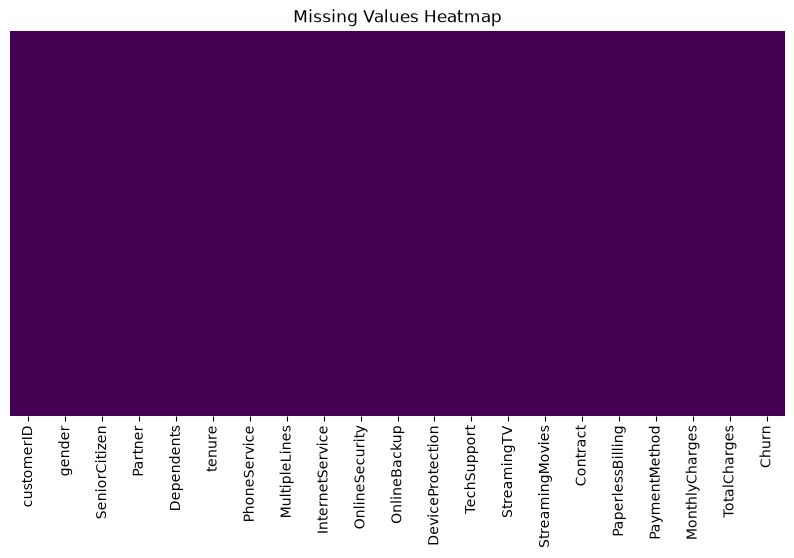

In [84]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

## Duplicates

In [85]:
df.duplicated().sum()

np.int64(0)

## Numeric Distribution & Outliers

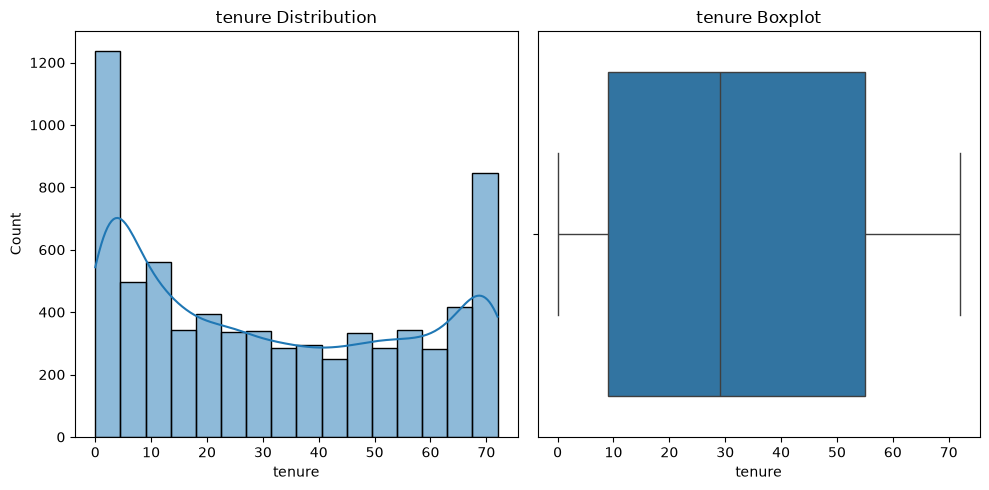

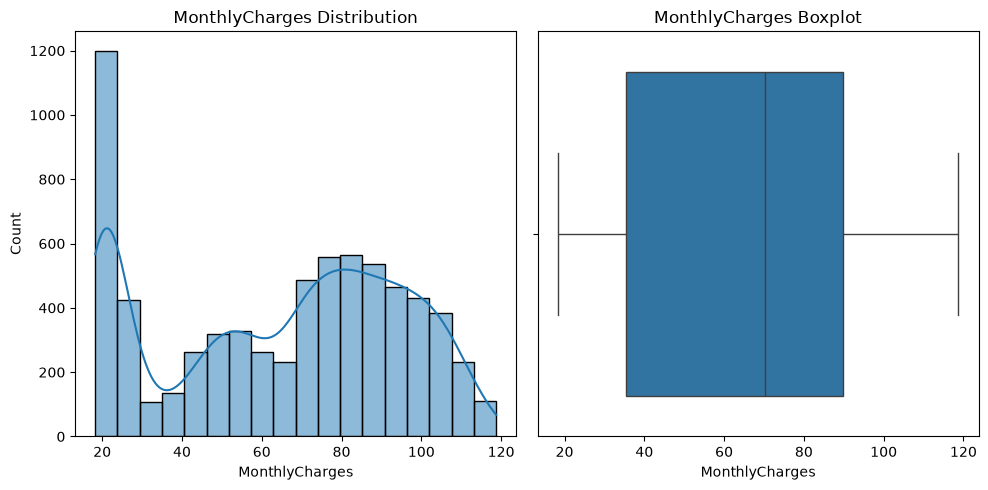

In [86]:
num_cols = ['tenure', 'MonthlyCharges']

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f"{col} Distribution")
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"{col} Boxplot")
    plt.tight_layout()
    plt.savefig(f"../outputs/figures/distributions/{col.lower()}_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

## Categorical Distribution

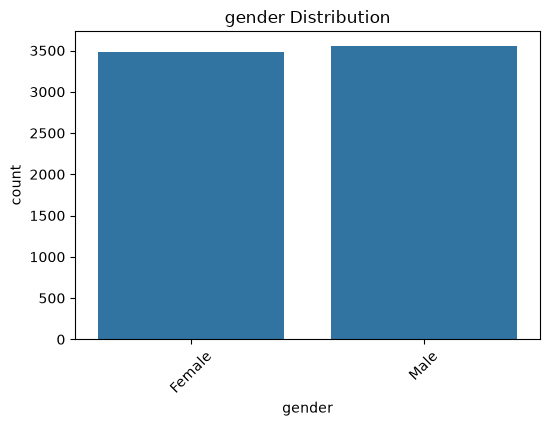

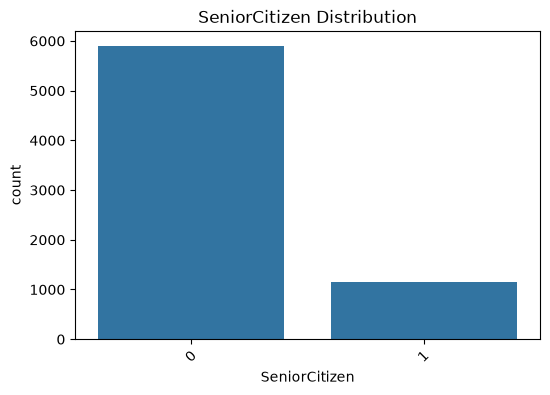

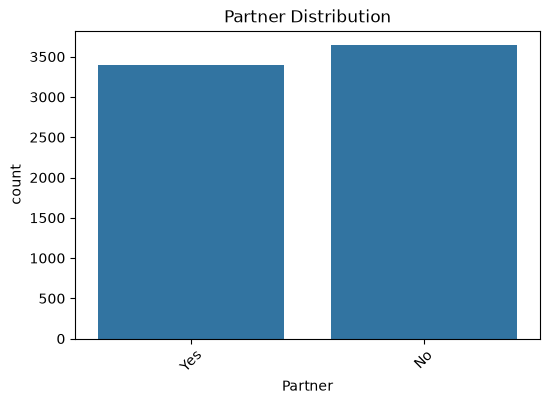

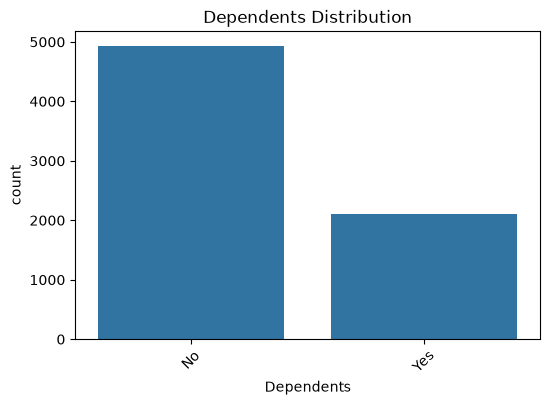

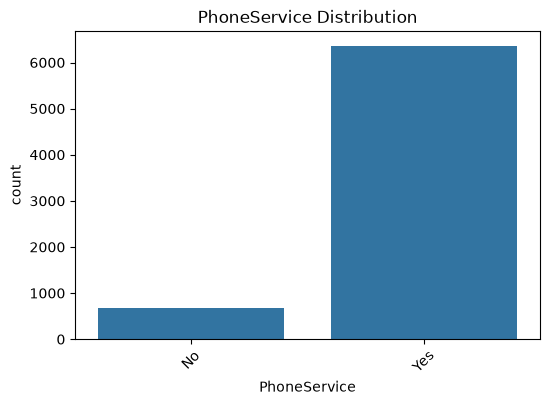

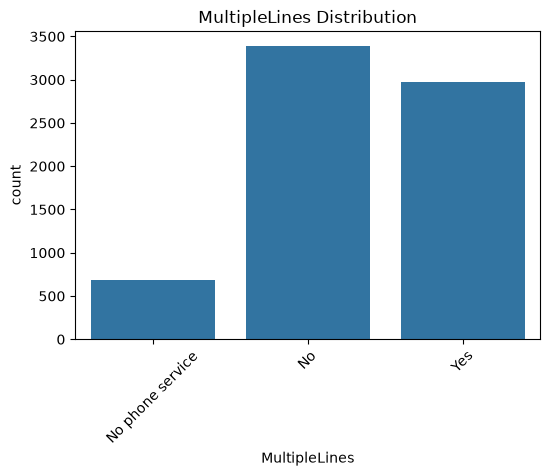

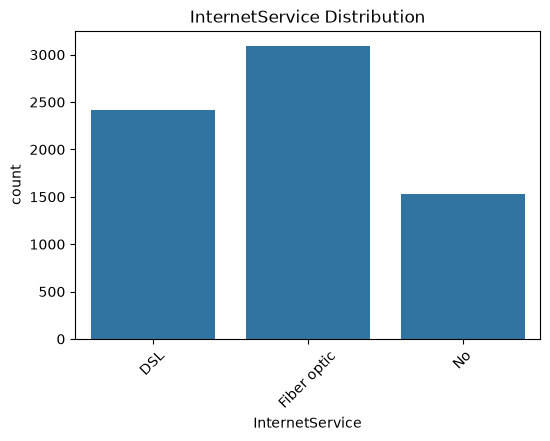

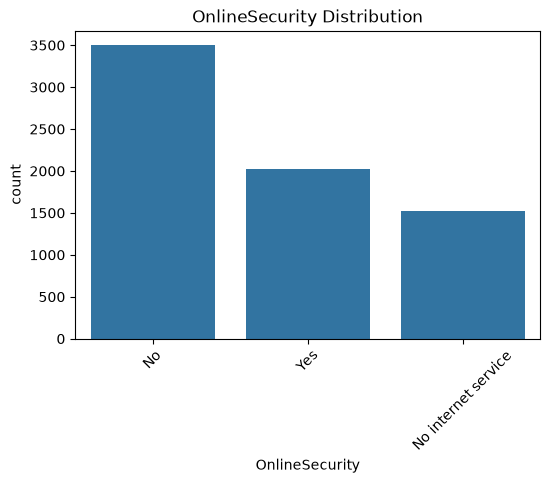

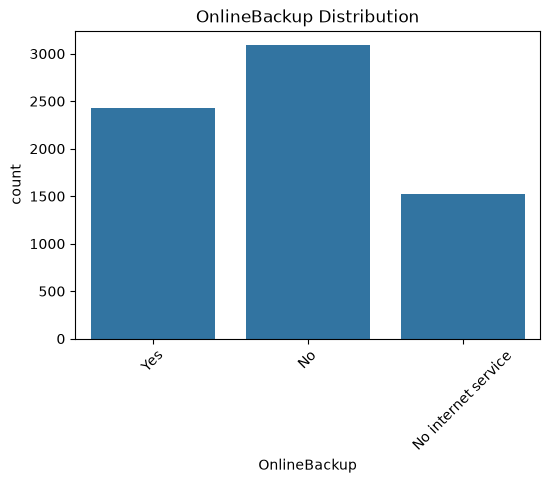

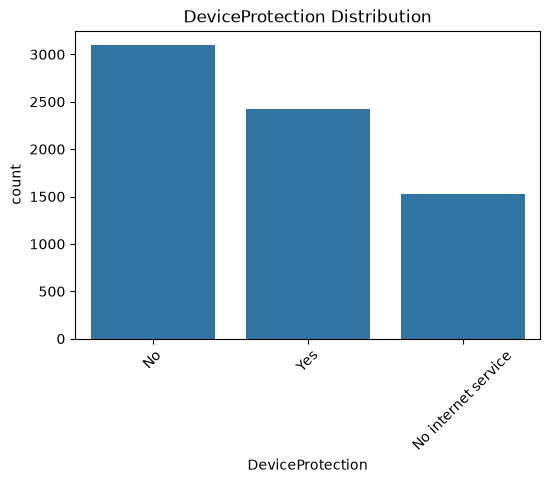

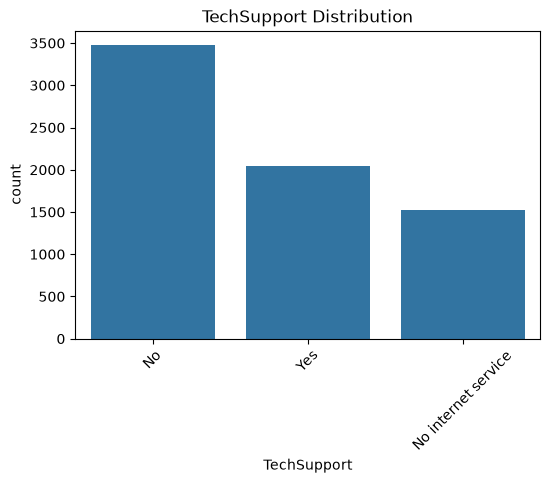

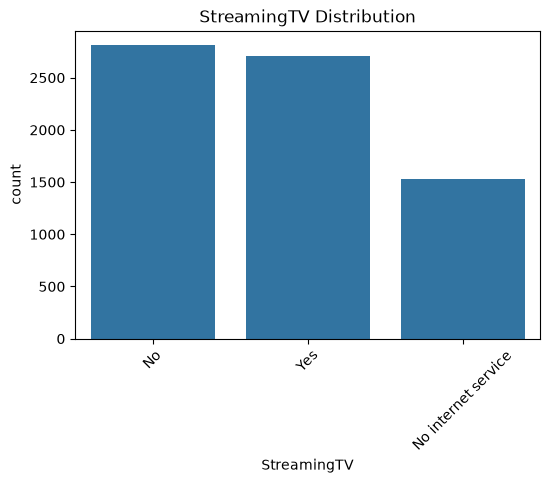

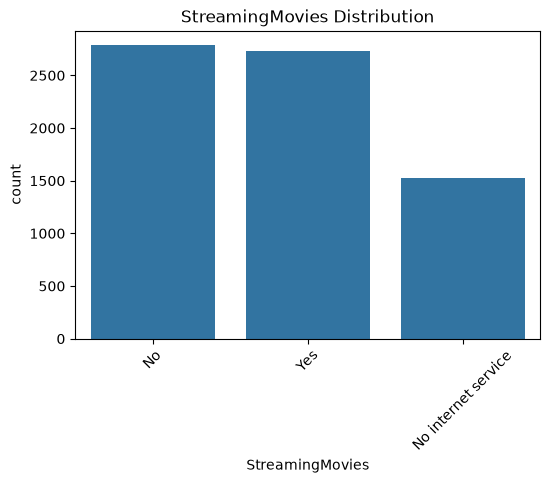

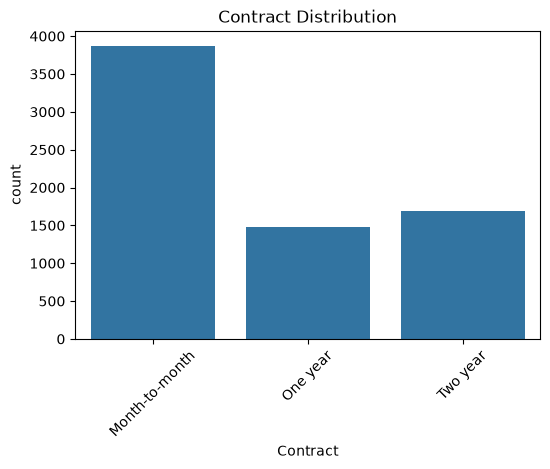

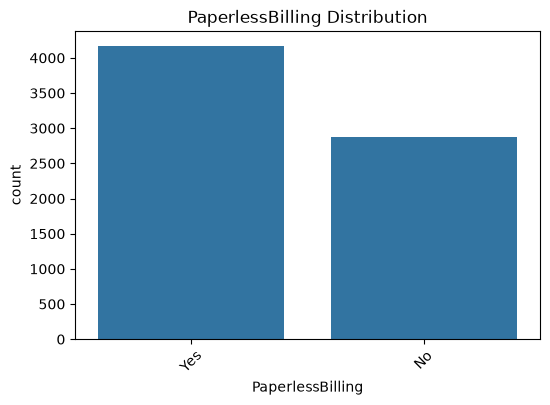

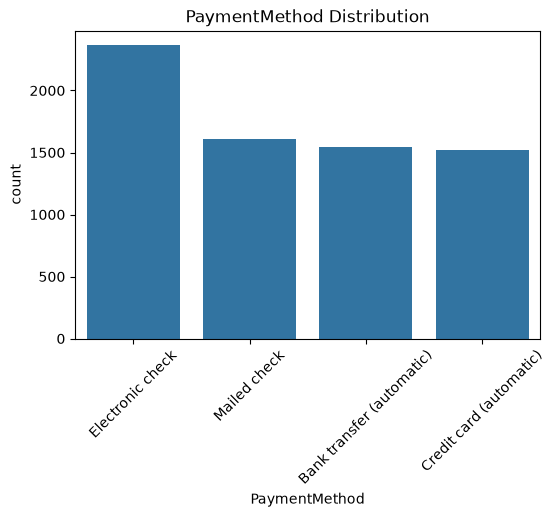

In [87]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod',
            'TotalCharges']

cat_cols_save = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity']

for col in cat_cols:
    if df[col].nunique() <= 15:
        plt.figure(figsize=(6,4))
        sns.countplot(data=df, x=col)
        plt.xticks(rotation=45)
        plt.title(f"{col} Distribution")
        for col in cat_cols_save:
            plt.savefig(f"../outputs/figures/distributions/{col.lower()}_distribution.png", dpi=300, bbox_inches="tight")
        plt.show()

## Target Distribution

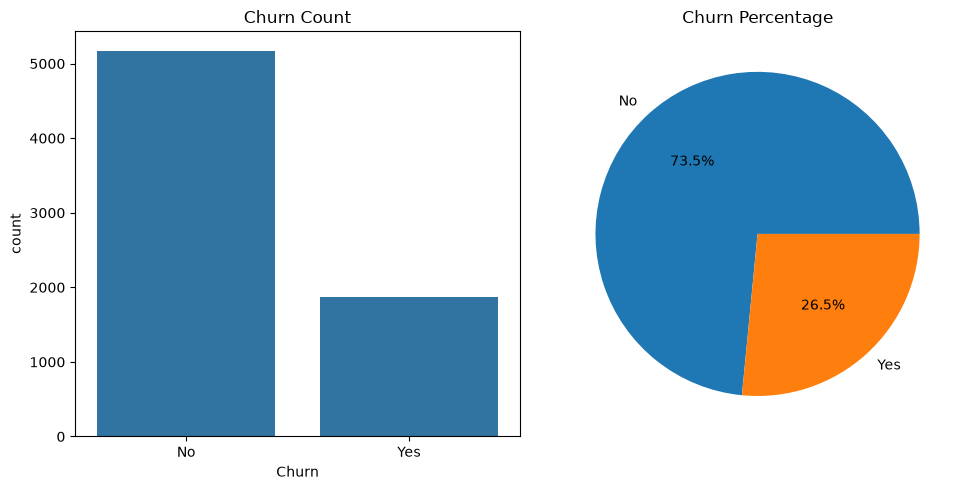

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.countplot(data=df, x='Churn', ax=axes[0])
axes[0].set_title('Churn Count')
df['Churn'].value_counts().plot(kind='pie',autopct='%1.1f%%',ax=axes[1])
axes[1].set_ylabel('')
axes[1].set_title('Churn Percentage')
plt.tight_layout()
plt.savefig(f"../outputs/figures/target/churn.png", dpi=300, bbox_inches="tight")
plt.show()

## Relationship

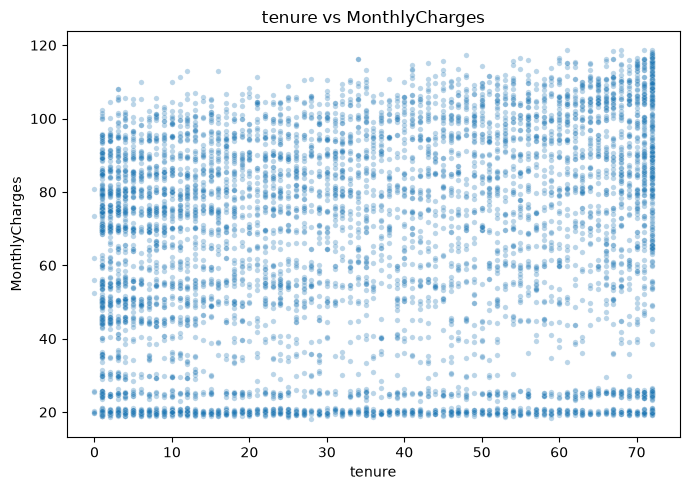

In [89]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges',alpha=0.3,s=15)
plt.title('tenure vs MonthlyCharges')
plt.tight_layout()
plt.savefig(f"../outputs/figures/relationships/tenure_vs_monthlycharges.png", dpi=300, bbox_inches="tight")
plt.show()

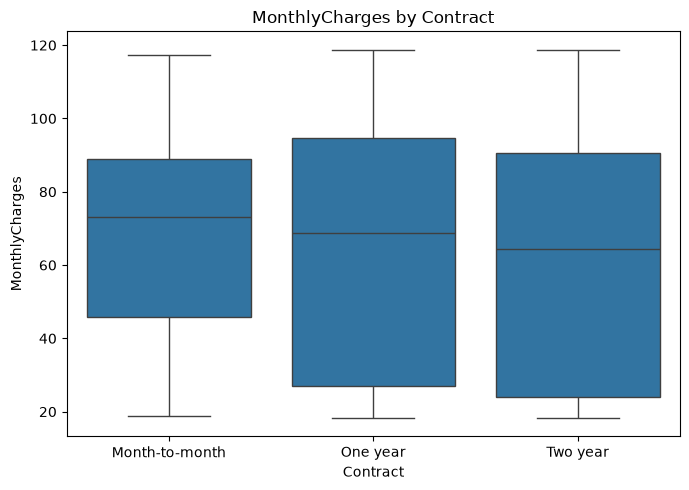

In [90]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Contract', y='MonthlyCharges')
plt.title('MonthlyCharges by Contract')
plt.tight_layout()
plt.savefig(f"../outputs/figures/relationships/monthlycharges_by_contract.png", dpi=300, bbox_inches="tight")
plt.show()

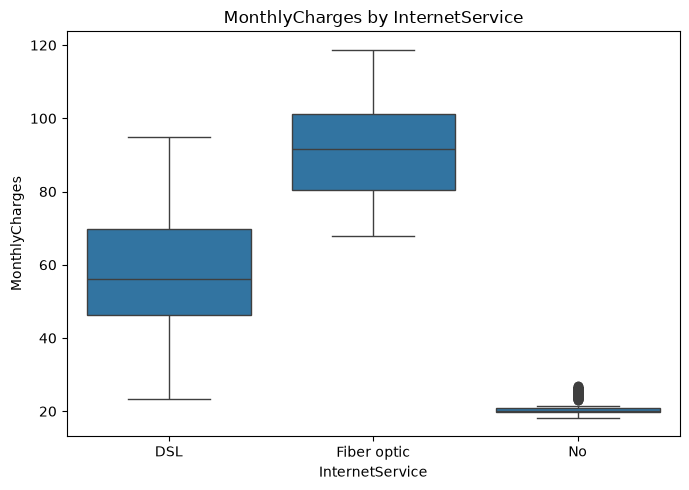

In [91]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='InternetService', y='MonthlyCharges')
plt.title('MonthlyCharges by InternetService')
plt.tight_layout()
plt.savefig(f"../outputs/figures/relationships/monthlycharges_by_internetservice.png", dpi=300, bbox_inches="tight")
plt.show()

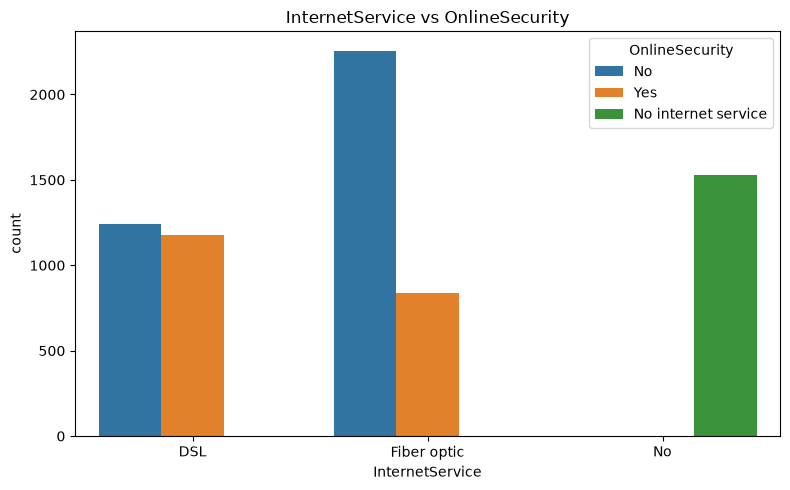

In [92]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='InternetService', hue='OnlineSecurity')
plt.title('InternetService vs OnlineSecurity')
plt.tight_layout()
plt.savefig(f"../outputs/figures/relationships/internetservice_vs_onlinesecurity.png", dpi=300, bbox_inches="tight")
plt.show()

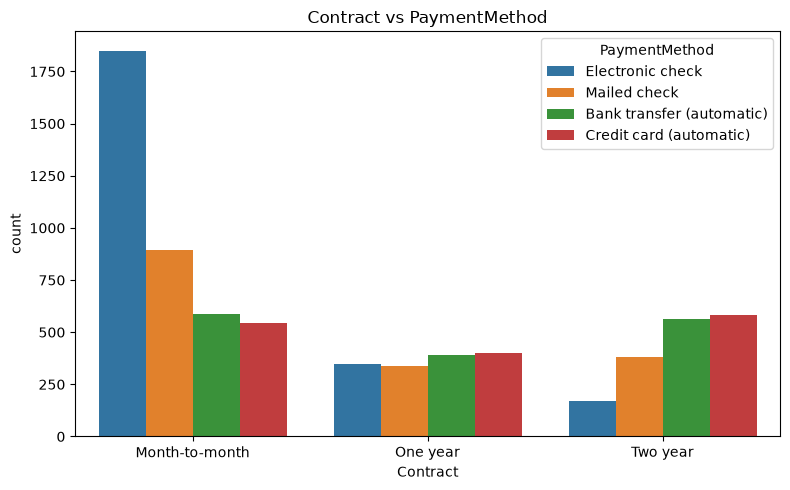

In [93]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='PaymentMethod')
plt.title('Contract vs PaymentMethod')
plt.tight_layout()
plt.savefig(f"../outputs/figures/relationships/contract_vs_paymentmethod.png", dpi=300, bbox_inches="tight")
plt.show()

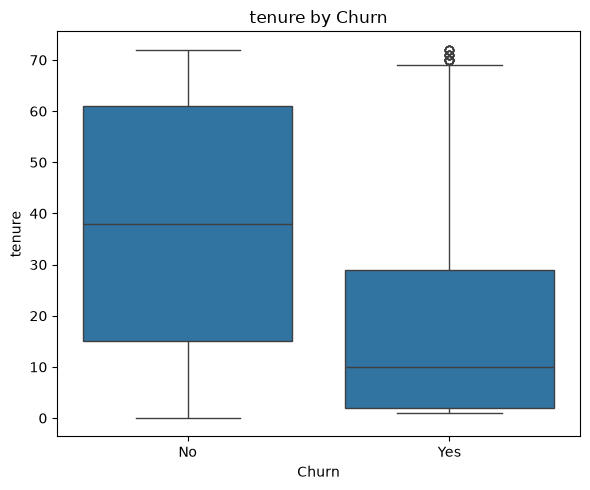

In [94]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('tenure by Churn')
plt.tight_layout()
plt.savefig(f"../outputs/figures/relationships/tenure_by_churn.png", dpi=300, bbox_inches="tight")
plt.show()

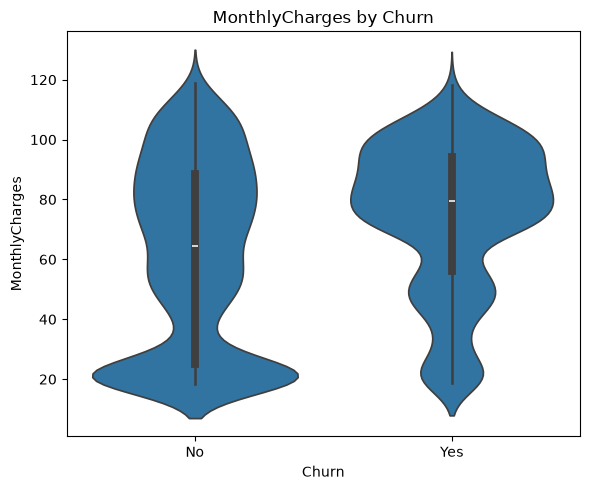

In [95]:
plt.figure(figsize=(6, 5))
sns.violinplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('MonthlyCharges by Churn')
plt.tight_layout()
plt.savefig(f"../outputs/figures/relationships/monthlycharges_by_churn.png", dpi=300, bbox_inches="tight")
plt.show()

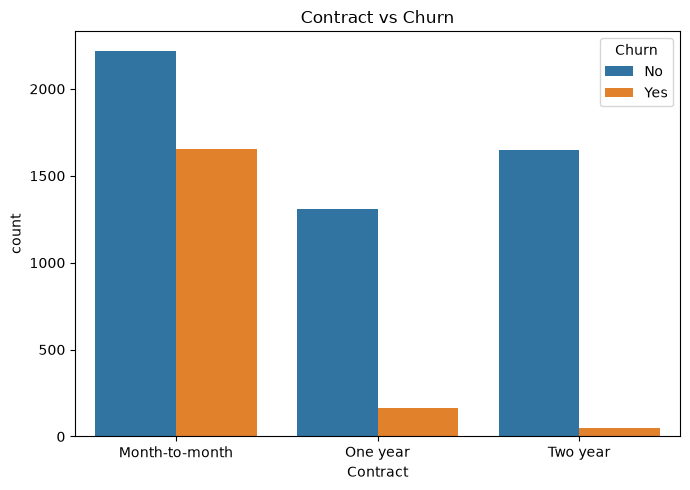

In [96]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Contract vs Churn')
plt.tight_layout()
plt.savefig(f"../outputs/figures/relationships/monthlycontract_by_churn.png", dpi=300, bbox_inches="tight")
plt.show()

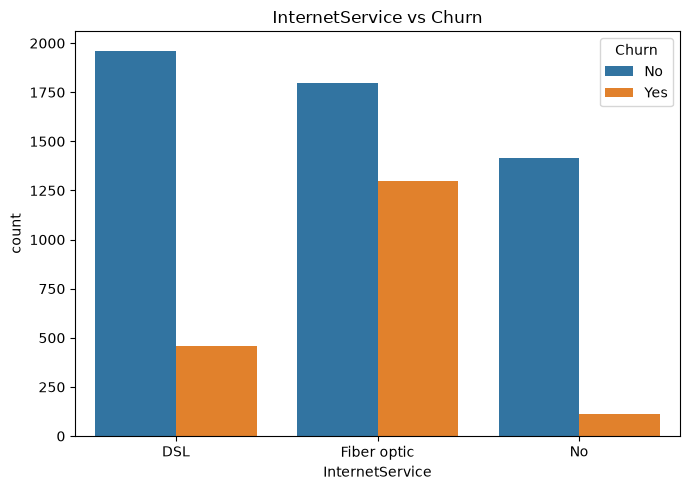

In [97]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('InternetService vs Churn')
plt.tight_layout()
plt.savefig(f"../outputs/figures/relationships/internetservice_by_churn.png", dpi=300, bbox_inches="tight")
plt.show()

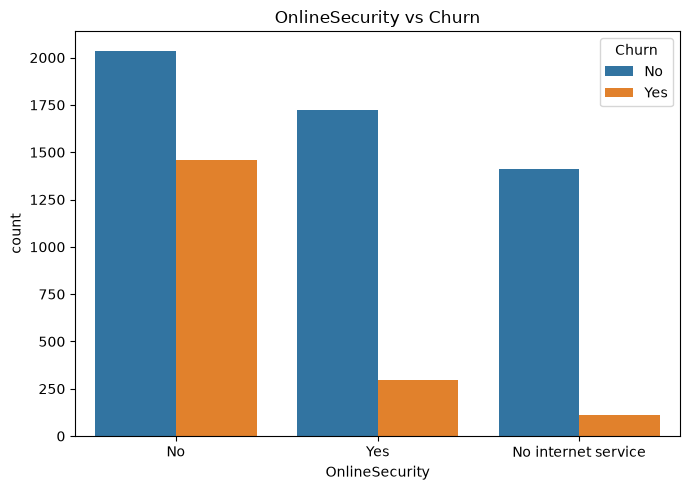

In [98]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='OnlineSecurity', hue='Churn')
plt.title('OnlineSecurity vs Churn')
plt.tight_layout()
plt.savefig(f"../outputs/figures/relationships/onlinesecurity_by_churn.png", dpi=300, bbox_inches="tight")
plt.show()

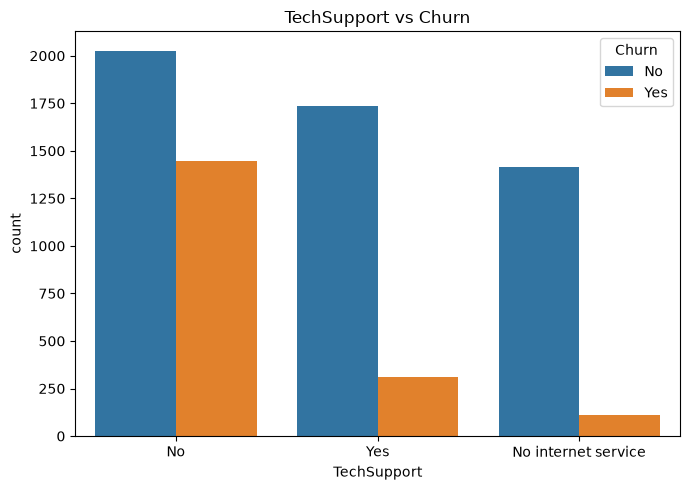

In [99]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='TechSupport', hue='Churn')
plt.title('TechSupport vs Churn')
plt.tight_layout()
plt.savefig(f"../outputs/figures/relationships/techsupport_by_churn.png", dpi=300, bbox_inches="tight")
plt.show()